Load the necessary libraries

In [1]:
#Load the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
print(sys.executable)

c:\Users\Niraksha G\AppData\Local\Programs\Python\Python311\python.exe


In [4]:
import sys
!{sys.executable} -m pip install seaborn

'c:\Users\Niraksha' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
#Load the dataset 
df = pd.read_csv("Bank Customer Churn Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Understanding the dataset
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [4]:
df.info


<bound method DataFrame.info of       customer_id  credit_score  country  gender  age  tenure    balance  \
0        15634602           619   France  Female   42       2       0.00   
1        15647311           608    Spain  Female   41       1   83807.86   
2        15619304           502   France  Female   42       8  159660.80   
3        15701354           699   France  Female   39       1       0.00   
4        15737888           850    Spain  Female   43       2  125510.82   
...           ...           ...      ...     ...  ...     ...        ...   
9995     15606229           771   France    Male   39       5       0.00   
9996     15569892           516   France    Male   35      10   57369.61   
9997     15584532           709   France  Female   36       7       0.00   
9998     15682355           772  Germany    Male   42       3   75075.31   
9999     15628319           792   France  Female   28       4  130142.79   

      products_number  credit_card  active_member  esti

In [5]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Preprocessing

In [ ]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

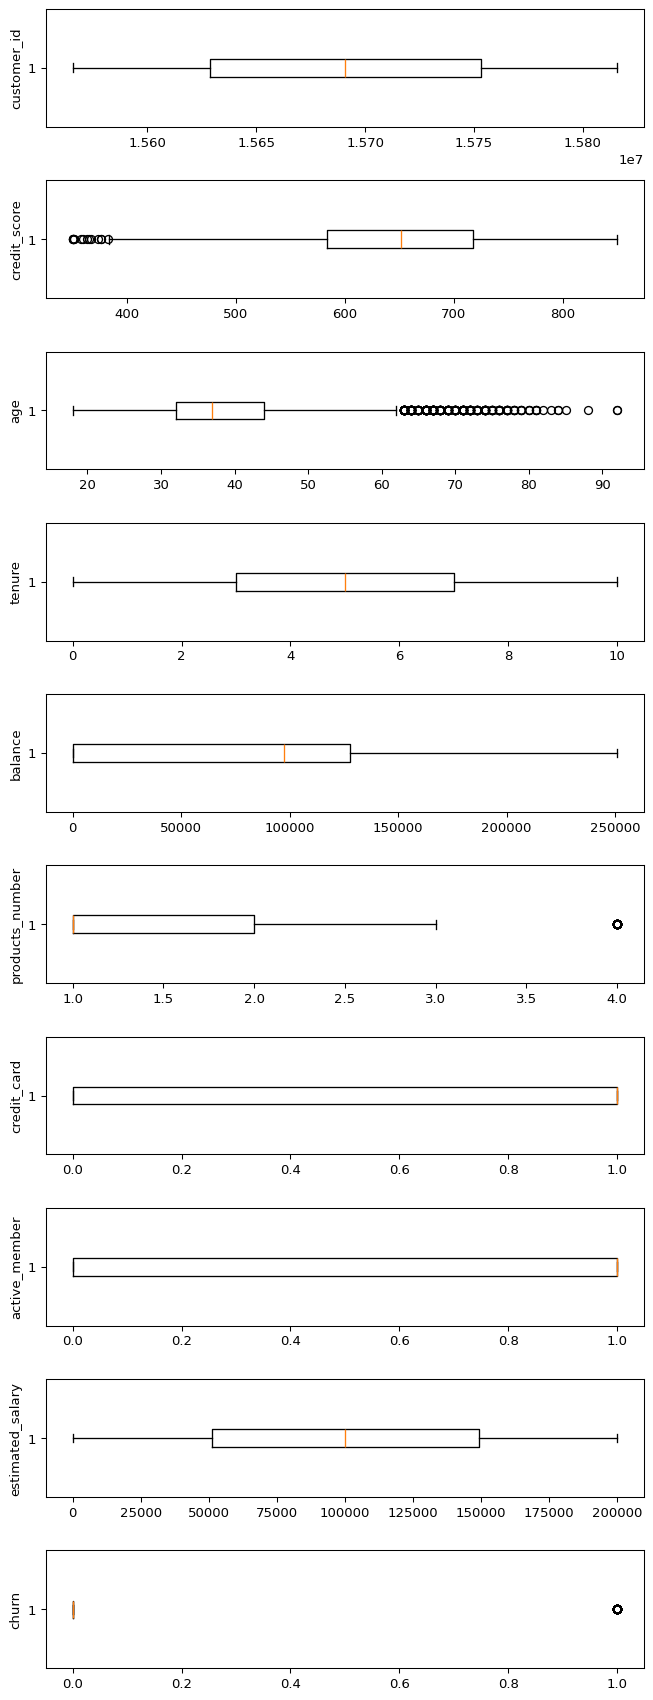

In [8]:
num_cols =df.select_dtypes(include=['int64','float64']).columns
fig,axs=plt.subplots(len(num_cols),1,figsize=(7,18),dpi=95)
for i,col in enumerate(num_cols):
    axs[i].boxplot(df[col],vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
# Boxplot was used to analyze and detect the outliers from the dataset for numerical features.
#Eventhough age and credit score have some outliers however these values are valid in real worl banking data and so they were retained


In [11]:
#Drop customer_id column
df.drop('customer_id',axis=1,inplace=True)

In [9]:
#One hot encoding
df=pd.get_dummies(df,columns=['country','gender'],drop_first=True)

In [ ]:
''' 
get_dummies is used of map because the map function creats an order(ranking) whereas the get_dummies
treats all categories equally
'''


#Exploratory Data Analysis

<Axes: xlabel='active_member', ylabel='Count'>

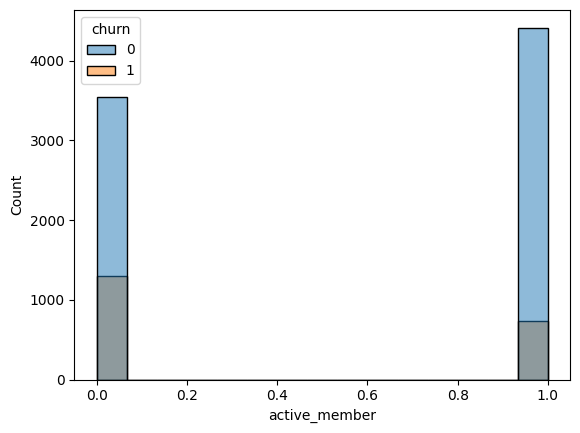

In [13]:
sns.histplot(
    data=df,
    x="active_member",
    hue="churn")

In [ ]:
'''
From the above plot we analyze that customers who are not active members have a higher
chance of churning whereas the active member stay with the bank. 
'''

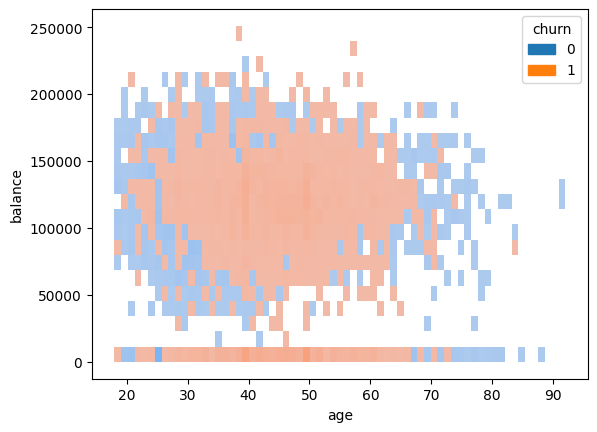

In [14]:
#Scatterplot
sns.histplot(
    data=df,
    x="age",
    y="balance",
    hue="churn",
)
plt.show()

In [ ]:
'''
From the above scatter plot we analyze that churned and non-churned customers are 
distributed across all age and balance ranges. There is no strong visible pattern indicating 
that age and balance are not sufficient to predict churn
'''

<Axes: xlabel='products_number', ylabel='balance'>

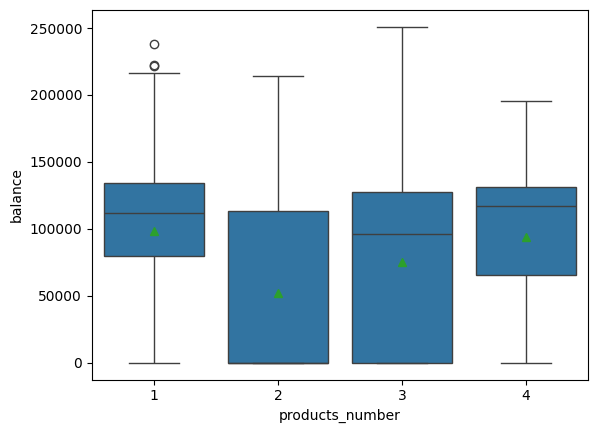

In [16]:
sns.boxplot(
    x="products_number",
    y="balance",
    showmeans=True,
    data=df
)

In [ ]:
'''
The above boxplot show that there is no clear relationship between the
number of products and balance as values are widely spread across all categories
'''

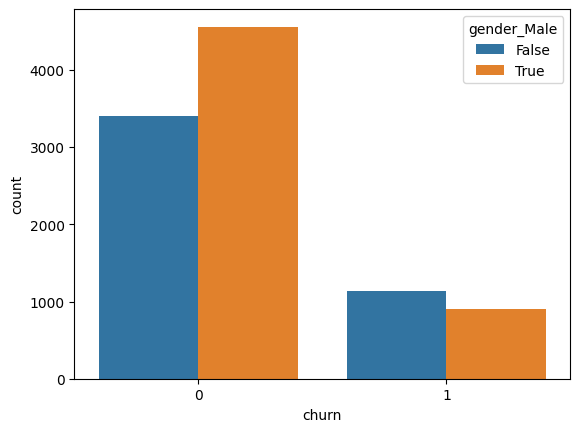

In [18]:
sns.countplot(x="churn",hue="gender_Male", data=df)
plt.show()

In [ ]:
#The above countplot shows that female customers have higher churn rate compared to male customers.

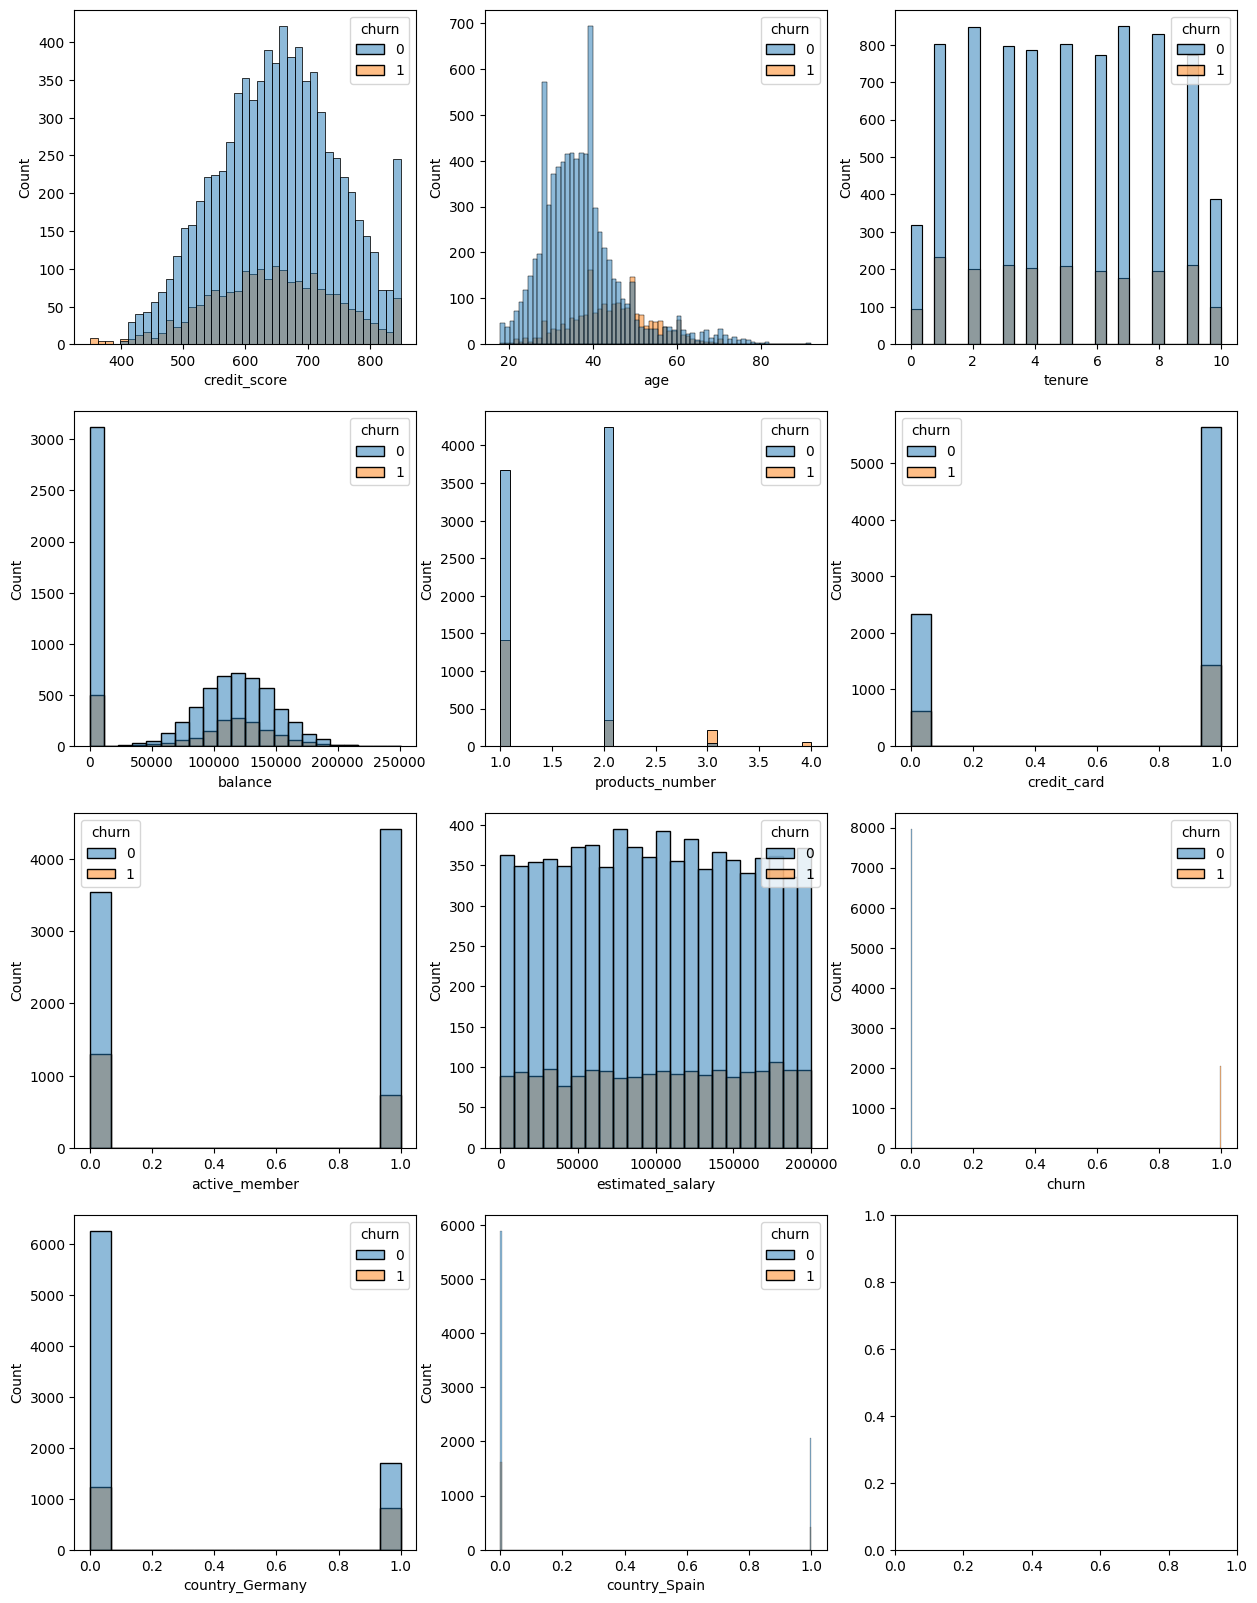

In [19]:
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15,20))
axs=axs.flat
for i in range(len(df.columns)-1):
    sns.histplot(data=df, x=df.columns[i],hue="churn",ax=axs[i])

In [ ]:
#From the above analysis age and active_membership shows a strong influence on churn.

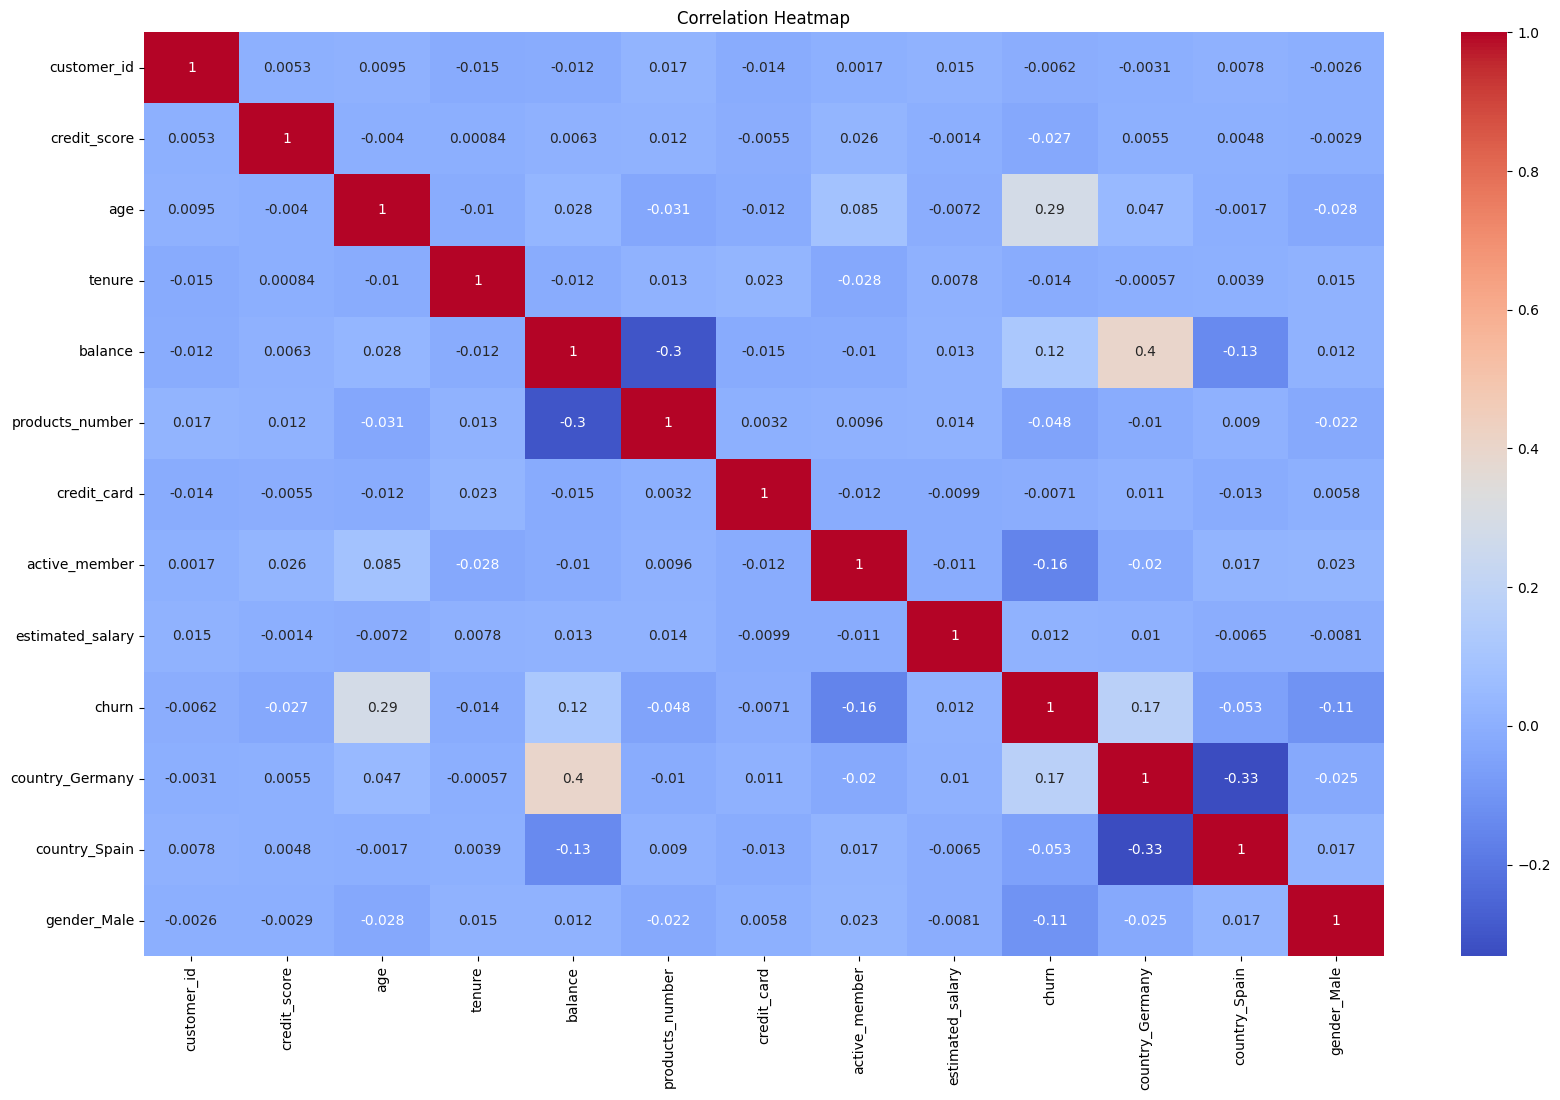

In [10]:
correlation_matrix = df.corr()
plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
'''
Correlation analysis shows that age has the strongest positive relationship with churn.
Active membership has a negative correlation.
Balance and country show a moderate influence while others have wak relationships.
It helps in feature selection
'''

Feature defining

In [ ]:
#Based on the above exploratory data analysis these features are choosen
features=['age','estimated_salary','products_number','active_member','balance','country_Germany','country_Spain','gender_Male']

In [12]:
X=df[features]
y=df['churn']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [14]:
#Train Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
# Install imbalanced-learn
import subprocess
subprocess.run(["pip", "install", "imbalanced-learn"], capture_output=True)

from imblearn.over_sampling import SMOTE

print("Before SMOTE:", y_train.value_counts().to_dict())

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train).value_counts().to_dict())

Before SMOTE: {0: 6356, 1: 1644}
After SMOTE: {0: 6356, 1: 6356}


In [16]:
#Scaling
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

Model 1 : Logistic Regression 

In [ ]:
lr=LogisticRegression()
lr.fit(X_train,y_train)
pred=lr.predict(X_test)
print("Logistic Regression Accuracy:",accuracy_score(y_test,pred))

Logistic Regression Accuracy: 0.738


In [18]:
print(classification_report(y_test, pred))
print("Confusion matrix")
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1607
           1       0.39      0.58      0.47       393

    accuracy                           0.74      2000
   macro avg       0.64      0.68      0.65      2000
weighted avg       0.79      0.74      0.76      2000

Confusion matrix
[[1247  360]
 [ 164  229]]


Model 2 : Random Forest Classifier 

In [ ]:
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,pred_rf))

Random Forest Accuracy: 0.8215


In [20]:
print(classification_report(y_test, pred_rf))
print("Confusion matrix")
print(confusion_matrix(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1607
           1       0.54      0.66      0.59       393

    accuracy                           0.82      2000
   macro avg       0.72      0.76      0.74      2000
weighted avg       0.84      0.82      0.83      2000

Confusion matrix
[[1385  222]
 [ 135  258]]


In [31]:
!pip install xgboost

     ------------------------------------ 101.7/101.7 MB 512.6 kB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Model 3 : XGBoost

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))
print("Confusion matrix")
print(confusion_matrix(y_test, pred_xgb))

XGBoost Accuracy: 0.8225
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1607
           1       0.54      0.66      0.59       393

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.84      0.82      0.83      2000

Confusion matrix
[[1385  222]
 [ 133  260]]


Model 4 : RUle Based Approach based on the EDA

In [ ]:
def rule_based_churn(row):
    if row['active_member']==0 and row['age']>45:
        return 1
    elif row['active_member']==0 and row['balance']>100000:
        return 1
    elif row['country_Germany']==1 and row['active_member']==0:
        return 1
    elif row['products_number']==1 and row['active_member']==0:
        return 1
    else:
        return 0
df['rule_based_pred']=df.apply(rule_based_churn,axis=1)

rule_acc=accuracy_score(df['churn'],df['rule_based_pred'])
print("="*45)
print("   RULE-BASED MODEL ACCURACY:", round(rule_acc * 100, 2), "%")
print("=" * 45)

print("\nClassification Report:")
print(classification_report(df['churn'], df['rule_based_pred']))

   RULE-BASED MODEL ACCURACY: 68.22 %

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      7963
           1       0.34      0.60      0.43      2037

    accuracy                           0.68     10000
   macro avg       0.61      0.65      0.61     10000
weighted avg       0.76      0.68      0.71     10000



In [32]:
!pip install lightgbm catboost

     ---------------------------------------- 1.5/1.5 MB 237.8 kB/s eta 0:00:00
     ------------------------------------ 100.2/100.2 MB 969.4 kB/s eta 0:00:00
     -------------------------------------- 47.3/47.3 kB 597.7 kB/s eta 0:00:00
  Using cached plotly-6.6.0-py3-none-any.whl (9.9 MB)



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Model 4 : VotingClassifier

In [ ]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier

In [24]:
xg=XGBClassifier(random_state=42)
lgb=LGBMClassifier(random_state=42)
cat=CatBoostClassifier(random_state=42)

voting_model=VotingClassifier(
                estimators=[('xg',xg),
                           ('lgb',lgb),
                           ('cat',cat)],
                    voting='soft')

In [25]:
voting_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 6356, number of negative: 6356
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 593
[LightGBM] [Info] Number of data points in the train set: 12712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Learning rate set to 0.030509
0:	learn: 0.6727634	total: 202ms	remaining: 3m 21s
1:	learn: 0.6538135	total: 208ms	remaining: 1m 43s
2:	learn: 0.6357350	total: 214ms	remaining: 1m 11s
3:	learn: 0.6192123	total: 219ms	remaining: 54.6s
4:	learn: 0.6049498	total: 225ms	remaining: 44.9s
5:	learn: 0.5907141	total: 232ms	remaining: 38.4s
6:	learn: 0.5782518	total: 239ms	remaining: 34s
7:	learn: 0.5662301	total: 246ms	remaining: 30.5s
8:	learn: 0.5552063	total: 252ms	remaining: 27.8s
9:	learn: 0.5450188	total: 258ms	remaining: 25.6s
10:	learn: 0.5351684	total: 264ms	

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('xg', ...), ('lgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None


In [26]:
pred_vote = voting_model.predict(X_test)
print("Voting Accuracy:", accuracy_score(y_test, pred_vote))
print(classification_report(y_test, pred_vote))
print("Confusion matrix")
print(confusion_matrix(y_test, pred_vote))

Voting Accuracy: 0.8315
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1607
           1       0.56      0.67      0.61       393

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.85      0.83      0.84      2000

Confusion matrix
[[1400  207]
 [ 130  263]]


c:\Users\Niraksha G\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [27]:
df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

Visualizations

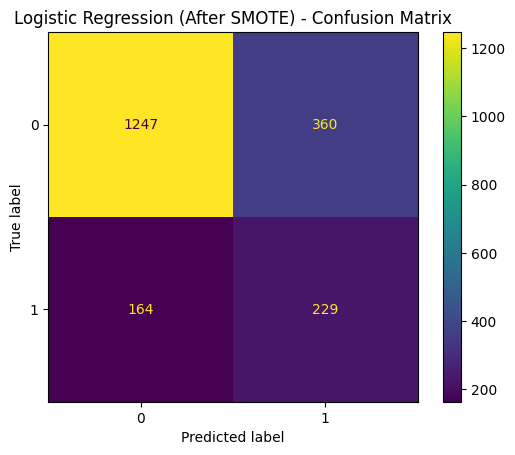

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("Logistic Regression (After SMOTE) - Confusion Matrix")
plt.show()

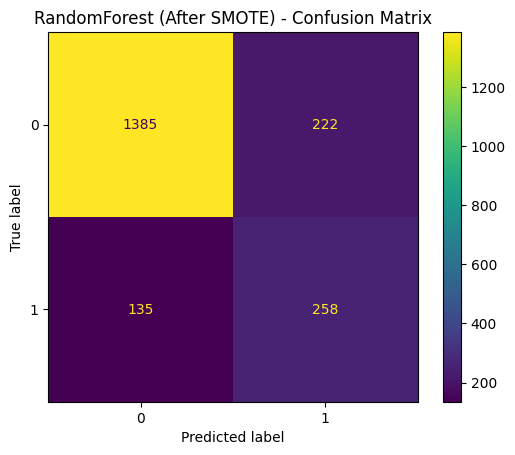

In [30]:
# RandomForest
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)
plt.title("RandomForest (After SMOTE) - Confusion Matrix")
plt.show()

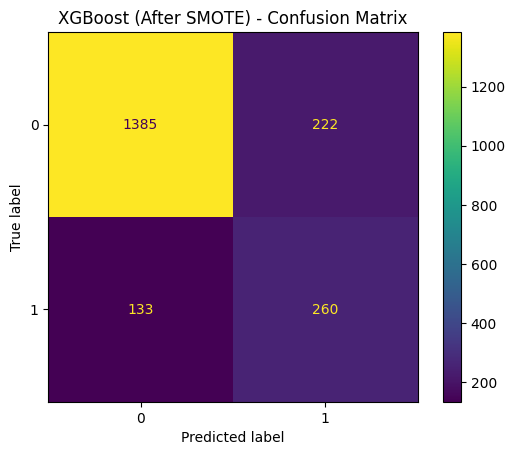

In [ ]:
# XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, pred_xgb)
plt.title("XGBoost (After SMOTE) - Confusion Matrix")
plt.show()

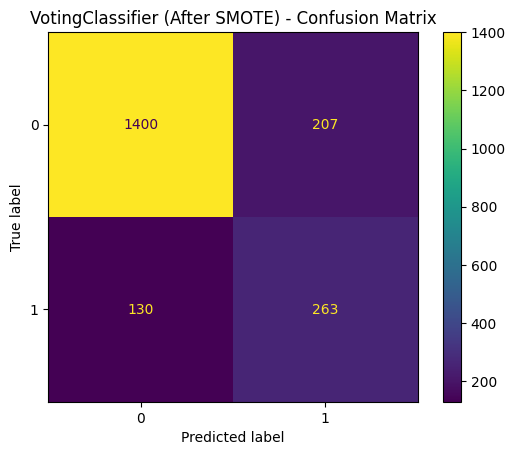

In [31]:
# VotingClassifier
ConfusionMatrixDisplay.from_predictions(y_test, pred_vote)
plt.title("VotingClassifier (After SMOTE) - Confusion Matrix")
plt.show()

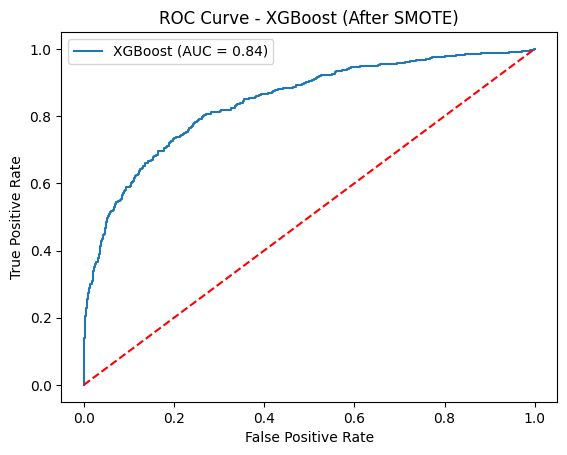

In [32]:
from sklearn.metrics import roc_curve, auc

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="XGBoost (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'r--')

plt.title("ROC Curve - XGBoost (After SMOTE)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

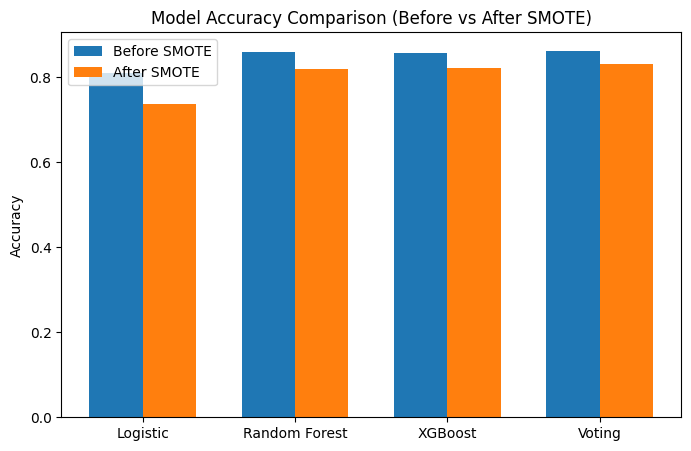

In [33]:
models = ['Logistic', 'Random Forest', 'XGBoost', 'Voting']

before_acc = [0.81, 0.86, 0.858, 0.863]
after_acc = [0.738, 0.8195, 0.8225, 0.8315]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, before_acc, width, label='Before SMOTE')
plt.bar(x + width/2, after_acc, width, label='After SMOTE')

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (Before vs After SMOTE)")
plt.legend()

plt.show()

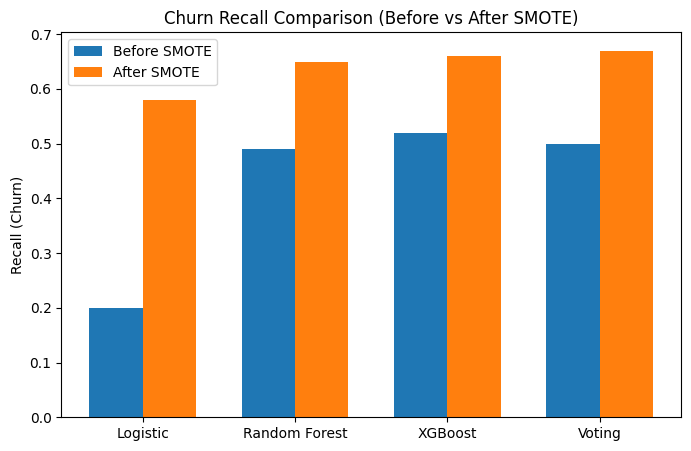

In [34]:
before_recall = [0.20, 0.49, 0.52, 0.50]
after_recall = [0.58, 0.65, 0.66, 0.67]

plt.figure(figsize=(8,5))

plt.bar(x - width/2, before_recall, width, label='Before SMOTE')
plt.bar(x + width/2, after_recall, width, label='After SMOTE')

plt.xticks(x, models)
plt.ylabel("Recall (Churn)")
plt.title("Churn Recall Comparison (Before vs After SMOTE)")
plt.legend()

plt.show()

c:\Users\Niraksha G\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


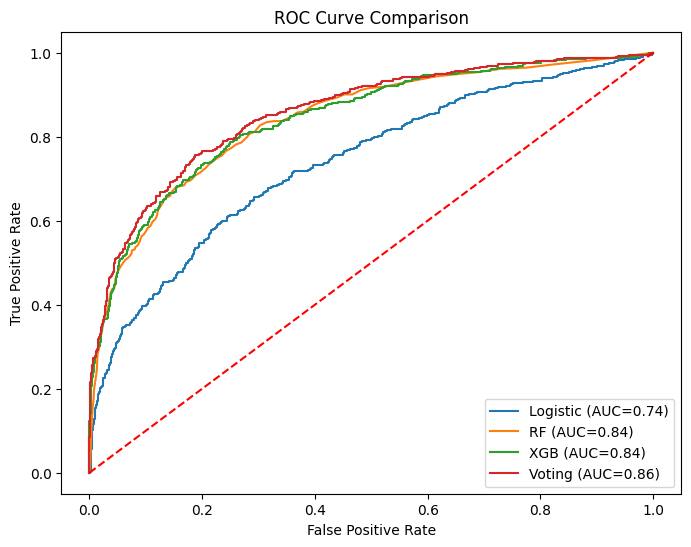

In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_prob_xgb = xgb.predict_proba(X_test)[:,1]
y_prob_vote = voting_model.predict_proba(X_test)[:,1]

# ROC values
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_vote, tpr_vote, _ = roc_curve(y_test, y_prob_vote)

# AUC
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_vote = auc(fpr_vote, tpr_vote)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC={auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC={auc_xgb:.2f})")
plt.plot(fpr_vote, tpr_vote, label=f"Voting (AUC={auc_vote:.2f})")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

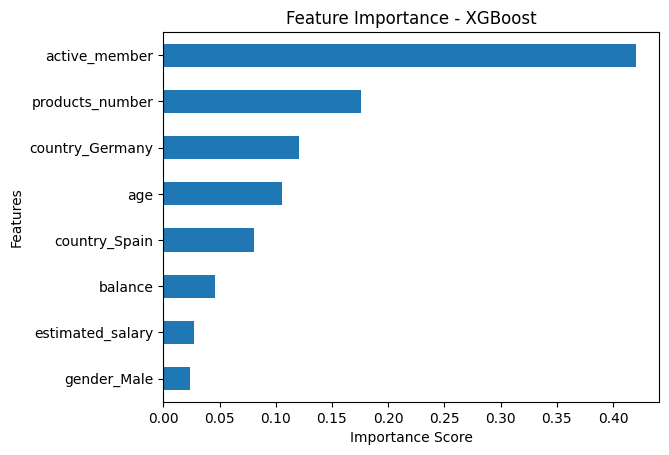

In [36]:
importance = xgb.feature_importances_
feat_importance = pd.Series(importance, index=X.columns)
feat_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Hyperparameter Tuning - XGBoost

In [37]:
#Hyper parametr Tuning 
from sklearn.model_selection import GridSearchCV
xgb = XGBClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(xgb, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [38]:
best_xgb = grid.best_estimator_

pred_best = best_xgb.predict(X_test)

In [39]:
print("Tuned XGBoost Accuracy:", accuracy_score(y_test, pred_best))
print("\nClassification Report:")
print(classification_report(y_test, pred_best))

Tuned XGBoost Accuracy: 0.826

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1607
           1       0.54      0.69      0.61       393

    accuracy                           0.83      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.85      0.83      0.83      2000



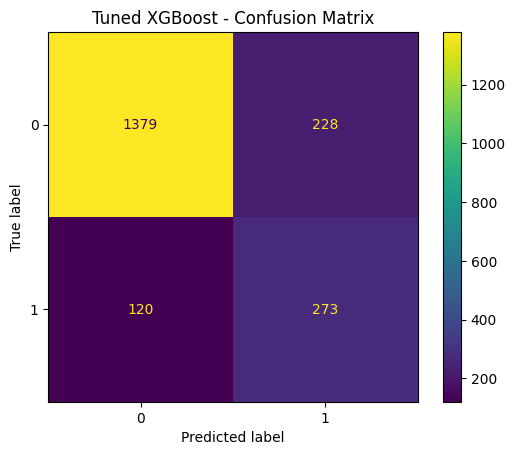

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_best)
plt.title("Tuned XGBoost - Confusion Matrix")
plt.show()

c:\Users\Niraksha G\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


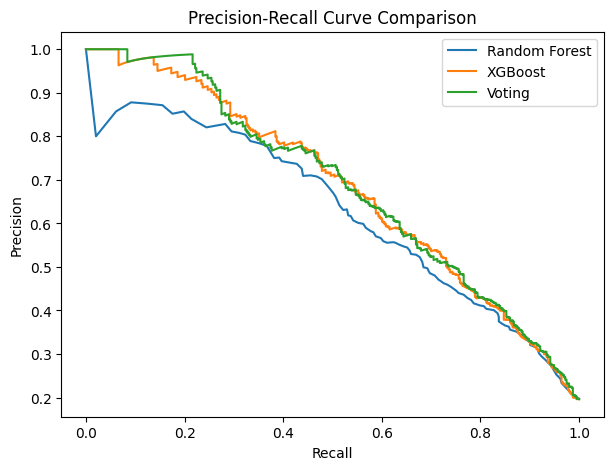

In [44]:
from sklearn.metrics import precision_recall_curve, auc
# Probabilities
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]
y_prob_vote = voting_model.predict_proba(X_test)[:,1]

# Curves
p_rf, r_rf, _ = precision_recall_curve(y_test, y_prob_rf)
p_xgb, r_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
p_vote, r_vote, _ = precision_recall_curve(y_test, y_prob_vote)

# Plot
plt.figure(figsize=(7,5))

plt.plot(r_rf, p_rf, label="Random Forest")
plt.plot(r_xgb, p_xgb, label="XGBoost")
plt.plot(r_vote, p_vote, label="Voting")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.show()

Prediction 

In [45]:
age = int(input("Enter Age: "))
salary = float(input("Enter Estimated Salary: "))
products = int(input("Enter Number of Products: "))
active = int(input("Active Member? (1=Yes, 0=No): "))
balance = float(input("Enter Balance: "))

print("\nCountry:")
print("France = 0, Germany = 1, Spain = 2")
country = int(input("Enter country code: "))

print("\nGender:")
print("Female = 0, Male = 1")
gender = int(input("Enter gender: "))


Country:
France = 0, Germany = 1, Spain = 2

Gender:
Female = 0, Male = 1


In [46]:
# Convert country to one-hot
country_Germany = 1 if country == 1 else 0
country_Spain = 1 if country == 2 else 0

# Gender
gender_Male = 1 if gender == 1 else 0

# Final input array
input_data = np.array([[age, salary, products, active,
                        balance, country_Germany,
                        country_Spain, gender_Male]])


In [47]:
input_scaled = scaler.transform(input_data)
prediction = best_xgb.predict(input_scaled)

if prediction[0] == 1:
    print("\n Customer is likely to CHURN")
else:
    print("\n Customer is likely to STAY")


 Customer is likely to CHURN


c:\Users\Niraksha G\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
